In [1]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm

from Utils import Notebook, tex, gph, sgn, nm, ds
from petc_simulation import closed_loop_setm, open_loop
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [2]:
experiment_config_filename = 'experiment-2'

with open(f"experiment/{experiment_config_filename}.json", encoding='utf-8') as f:
  config = json.load(f)

sim_duration = config['simulation_duration']
sim_step = config.get("simulation_step", 1e-4)
timepts = np.arange(0, sim_duration + sim_step, sim_step)

plant = ds.StateSpace(data=config["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Simulação da Planta em Malha Aberta

In [3]:
# %%skip

x0 = np.array([[1.0], [-1.0]], dtype=np.float32)
plant_output, time_history, signal_control, _, _ = open_loop(
    x0, config, u_constant=0.0)

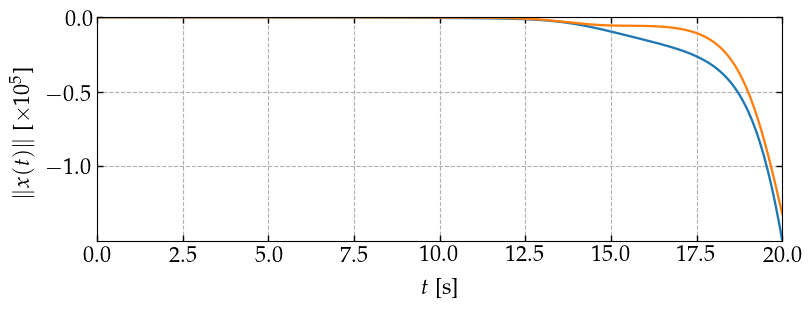

In [4]:
# %%skip

fig = plt.figure(figsize=(8, 3), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

y = plant_output
t = time_history

x_norm = np.linalg.norm(y, axis=0)
xnorm_f, xnorm_ul = nm.format_magnitudes(x_norm)

_ = gph.plot(
    axs['x'], t, [y[0], y[1]],
    xlabel='$t$', x_unit='s',  x_use_prefixes=True,
    ylabel=r'$\|x(t)\|$'
)

### Projeto do Controlador e do ETM

In [5]:
plant_data = {
    'nx': plant.nx, 'nu': plant.nu, 'nρ': plant.n_rho, 'nw': plant.nw, 'nz': plant.nz,
    'ρ_bounds': plant.get_parameter_bounds(),
    'u_bar': plant.get_input_bounds()[0],
    'matrices_func': lambda ρi: plant.matrices_func(ρi),
}

design_params = config["design_params"]["dspetc"]

In [59]:
def control_synthesis_exp(
    plant_data: Dict[str, Any],
    design_params: Dict[str, float],
    eps: float = 1e-6,
    solver: Any = cp.MOSEK,
    dtype=np.float64
) -> Optional[Dict[str, Any]]:
  """
  Sintetiza o ganho K e as matrizes do SETM (Ξ, Ψ) para sistemas LPV/LIT contínuos 
  amostrados periodicamente via LMIs (Looped-Lyapunov Functional).

  Parameters
  ----------
  plant_data : Dict[str, Any]
      - 'nx': dimensão do estado
      - 'nu': dimensão da entrada
      - 'nρ': número de parâmetros LPV (0 para sistemas LIT)
      - 'ρ_bounds': limites dos parâmetros [[min, max], ...]
      - 'matrices_func': função que recebe ρi e retorna {'A': A_cont, 'B': B_cont} (MATRIZES CONTÍNUAS)
  design_params : Dict[str, float]
      - 'h': período de amostragem fundamental
      - 'υ': parâmetro upsilon do funcional
      - 'λ': taxa de decaimento contínua desejada
  """
  nx = plant_data['nx']
  nu = plant_data['nu']
  nρ = plant_data.get('nρ', 0)
  ρ_bounds = plant_data.get('ρ_bounds', [])
  matrices_func = plant_data['matrices_func']

  h = float(design_params['h'])
  υ = float(design_params['υ'])
  λ = float(design_params['λ'])

  # Geração dos vértices do hipercubo de parâmetros (se nρ=0, retorna [()])
  if nρ > 0:
    Bnp = list(itertools.product([0, 1], repeat=nρ))
  else:
    Bnp = [()]

  Onx = np.zeros((nx, nx), dtype=dtype)

  # 1. Carregamento das matrizes CONTÍNUAS dos vértices da planta
  A, B = {}, {}
  for i in Bnp:
    if nρ > 0:
      ρi = [ρ_bounds[idx][i[idx]] for idx in range(nρ)]
    else:
      ρi = []
    mats = matrices_func(ρi)
    A[i] = cp.Parameter((nx, nx), value=mats['A'].astype(dtype))
    B[i] = cp.Parameter((nx, nu), value=mats['B'].astype(dtype))

  # Matrizes de projeção do bloco estendido (5 * nx)
  e = nm.get_e(5 * [nx])
  for i_idx in range(1, len(e)):
    e[i_idx] = cp.Parameter(e[i_idx].shape, value=e[i_idx].astype(dtype))

  # 2. Variáveis de Decisão Convexas
  Ptil = cp.Variable((nx, nx), PSD=True)
  Mtil = cp.Variable((2 * nx, 2 * nx), PSD=True)
  Q1til = cp.Variable((nx, nx), symmetric=True)
  Q2til = cp.Variable((nx, nx))
  Q3til = cp.Variable((nx, nx))
  S1til = cp.Variable((nx, nx), symmetric=True)
  S2til = cp.Variable((nx, nx))
  S3til = cp.Variable((nx, nx))
  Ktil = cp.Variable((nu, nx))

  Rtil = cp.Variable((nx, nx), PSD=True)
  Ξtil = cp.Variable((nx, nx), PSD=True)
  Ψtil = cp.Variable((nx, nx), PSD=True)
  X = cp.Variable((nx, nx))
  Ytil = cp.Variable((2 * nx, e[1].shape[1]))

  # 3. Expressões Auxiliares e Funcionais
  Rcal = cp.bmat([[Rtil, Onx], [Onx, 3.0 * Rtil]])
  Fscr = e[1].T + υ * e[2].T + υ * e[4].T
  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]], [e[1] + e[2] - 2.0 * e[3]]])

  Λ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
      nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))

  Λ2 = κ1.T @ Mtil @ κ1 - e[4].T @ Rtil @ e[4] - e[3].T @ Q1til @ e[3] + \
      nm.He((e[1] - e[2]).T @ S1til @ e[4] + e[4].T @ S2til @ e[2] +
            e[4].T @ S3til @ e[5] + e[1].T @ Q1til @ e[3] +
            e[1].T @ Q2til @ e[2] + e[1].T @ Q3til @ e[5])

  Λ3 = e[3].T @ Q1til @ e[3] + κ1.T @ Mtil @ κ1 + \
      nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))

  exp_λh = np.exp(-2.0 * λ * h)

  def get_Θ0(v_idx):
    Bscr = A[v_idx] @ X @ e[1] + B[v_idx] @ Ktil @ e[2] + \
        B[v_idx] @ Ktil @ e[5] - X @ e[4]
    return - e[5].T @ Ξtil @ e[5] - 2.0 * λ * exp_λh * Λ1 + (1.0 - exp_λh) * Λ2 + \
        nm.He(Fscr @ Bscr + e[1].T @ Ptil @ e[4] + λ * e[1].T @ Ptil @ e[1] -
              2.0 * λ * exp_λh * κ2.T @ Ytil)

  def get_Θh(v_idx):
    Bscr = A[v_idx] @ X @ e[1] + B[v_idx] @ Ktil @ e[2] + \
        B[v_idx] @ Ktil @ e[5] - X @ e[4]
    return - e[5].T @ Ξtil @ e[5] - 2.0 * λ * exp_λh * (Λ1 + h * Λ3 + nm.He(κ2.T @ Ytil)) + \
        nm.He(Fscr @ Bscr + e[1].T @ Ptil @
              e[4] + λ * e[1].T @ Ptil @ e[1])

  def get_Γ(v_idx):
    Γ1_11 = get_Θ0(v_idx)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θh(v_idx)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (np.exp(2.0 * λ * h) / (2.0 * λ * h)) * Rcal
    Γ2_23 = np.zeros((2 * nx, nx), dtype=dtype)

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  # 4. Adição das Restrições LMI para Todos os Vértices
  constraints = []
  for v_idx in Bnp:
    Γ1, Γ2 = get_Γ(v_idx)
    constraints += [Γ1 << -eps * np.eye(Γ1.shape[0], dtype=dtype)]
    constraints += [Γ2 << -eps * np.eye(Γ2.shape[0], dtype=dtype)]

  constraints += [Ψtil >> eps * np.eye(nx, dtype=dtype)]
  constraints += [Ξtil >> eps * np.eye(nx, dtype=dtype)]

  # 5. Problema de Otimização
  obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  try:
    prob.solve(solver=solver, verbose=False, ignore_dpp=True)
  except cp.SolverError:
    prob.solve(solver=cp.SCS, verbose=False)

  # 6. Reconstrução Robusta das Soluções
  if prob.status in [cp.OPTIMAL] and X.value is not None:
    X_val = X.value.astype(dtype)
    Xinv = np.linalg.inv(X_val)
    XinvT = Xinv.T

    Xinv_2x = np.block([[Xinv, np.zeros((nx, nx), dtype=dtype)],
                        [np.zeros((nx, nx), dtype=dtype), Xinv]])
    XinvT_2x = Xinv_2x.T

    # Recuperação do ETM e do Ganho K
    Ξ = XinvT @ Ξtil.value.astype(dtype) @ Xinv
    Ψ = np.linalg.inv(Ψtil.value.astype(dtype))
    K = Ktil.value.astype(dtype) @ Xinv

    # Recuperação das matrizes do Funcional
    P = XinvT @ Ptil.value.astype(dtype) @ Xinv
    R = XinvT @ Rtil.value.astype(dtype) @ Xinv
    M = XinvT_2x @ Mtil.value.astype(dtype) @ Xinv_2x
    Y = XinvT_2x @ Ytil.value.astype(dtype)

    return {
        'optimal_value': prob.value,
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'functional': {
            'P': P, 'R': R, 'M': M, 'Y': Y
        }
    }

  return None

In [37]:
import itertools
import numpy as np
import cvxpy as cp
from typing import Dict, Any


def control_synthesis_exp(
    plant_data: Dict[str, Any],
    design_params: Dict[str, float],
    eps: float = 1e-6,
    dtype=np.float32
):
  nx = plant_data['nx']
  nu = plant_data['nu']
  nρ = plant_data['nρ']
  ρ_bounds = plant_data['ρ_bounds']
  matrices_func = plant_data['matrices_func']

  h = design_params['h']
  υ = design_params['υ']
  λ = design_params['λ']

  Bnp = list(itertools.product([0, 1], repeat=nρ))
  Onx = np.zeros((nx, nx), dtype=dtype)

  # Plant matrices
  A, B = {}, {}
  for i in Bnp:
    ρi = [ρ_bounds[idx][i[idx]] for idx in range(nρ)]
    mats = matrices_func(ρi)
    A[i] = cp.Parameter((nx, nx), value=mats['A'].astype(dtype))
    B[i] = cp.Parameter((nx, nu), value=mats['B'].astype(dtype))

  e = nm.get_e(5*[nx])
  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i].astype(dtype))

  # Variables
  Ptil = cp.Variable((nx, nx), PSD=True)
  Mtil = cp.Variable((2*nx, 2*nx), PSD=True)
  Q1til = cp.Variable((nx, nx), symmetric=True)
  Q2til = cp.Variable((nx, nx))
  Q3til = cp.Variable((nx, nx))
  S1til = cp.Variable((nx, nx), symmetric=True)
  S2til = cp.Variable((nx, nx))
  S3til = cp.Variable((nx, nx))
  Ktil = cp.Variable((nu, nx))

  Rtil = cp.Variable((nx, nx), PSD=True)
  Ξtil = cp.Variable((nx, nx), PSD=True)
  Ψtil = cp.Variable((nx, nx), PSD=True)
  X = cp.Variable((nx, nx))
  Ytil = cp.Variable((2*nx, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx], [Onx, 3*Rtil]])
  Fscr = e[1].T + υ*e[2].T + υ*e[4].T
  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1]-e[2]], [e[1]+e[2]-2*e[3]]])

  constraints = []

  Λ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
      nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))

  Λ2 = κ1.T @ Mtil @ κ1 - e[4].T @ Rtil @ e[4] - e[3].T @ Q1til @ e[3] + \
      nm.He((e[1] - e[2]).T @ S1til @ e[4] + e[4].T @ S2til @ e[2] +
            e[4].T @ S3til @ e[5] + e[1].T @ Q1til @ e[3] + e[1].T @ Q2til @ e[2] + e[1].T @ Q3til @ e[5])

  Λ3 = e[3].T @ Q1til @ e[3] + κ1.T @ Mtil @ κ1 + \
      nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))

  exp_λh = np.exp(- 2. * λ * h)

  def get_Θ0(i):
    Bscr = A[i] @ X @ e[1] + B[i] @ Ktil @ e[2] + \
        B[i] @ Ktil @ e[5] - X @ e[4]
    return - e[5].T @ Ξtil @ e[5] - 2. * λ * exp_λh * Λ1 + (1. - exp_λh) * Λ2 + \
        nm.He(Fscr @ Bscr + e[1].T @ Ptil @ e[4] + λ * e[1].T @ Ptil @ e[1] +
              2. * λ * exp_λh * κ2.T @ Ytil)

  def get_Θh(i):
    Bscr = A[i] @ X @ e[1] + B[i] @ Ktil @ e[2] + \
        B[i] @ Ktil @ e[5] - X @ e[4]
    return - e[5].T @ Ξtil @ e[5] - 2. * λ * exp_λh * (Λ1 + h * Λ3 - nm.He(κ2.T @ Ytil)) + \
        nm.He(Fscr @ Bscr + e[1].T @ Ptil @
              e[4] + λ * e[1].T @ Ptil @ e[1])

  def get_Γ(i):
    Γ1_11 = get_Θ0(i)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θh(i)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (np.exp(2. * λ * h) / (2. * λ * h)) * Rcal
    Γ2_23 = np.zeros((2 * nx, nx))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  for i in nm.binary_set(nρ):
    LMI_SUM = {'0': 0., 'h': 0.}
    Λ0, Λh = get_Γ(i)
    LMI_SUM['0'] += Λ0
    LMI_SUM['h'] += Λh
    constraints += [LMI_SUM['0'] << -eps *
                    np.eye(LMI_SUM['0'].shape[0], dtype=dtype)]
    constraints += [LMI_SUM['h'] << -eps *
                    np.eye(LMI_SUM['h'].shape[0], dtype=dtype)]

  constraints += [Ψtil >> eps*np.eye(nx, dtype=dtype)]
  constraints += [Ξtil >> eps*np.eye(nx, dtype=dtype)]

  # Objective
  obj = cp.Minimize(cp.trace(Ξtil+Ψtil))
  prob = cp.Problem(obj, constraints)
  prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # Results Reconstruction
  design_results = None
  if prob.status not in ["infeasible", "unbounded"]:
    # Matriz inversa auxiliar de congruência
    X_val = X.value.astype(dtype)
    Xinv = np.linalg.inv(X_val)
    XinvT = Xinv.T

    # Bloco estendido de congruência para matrizes de tamanho (2nx x 2nx)
    Xinv_2x = np.block([[Xinv, np.zeros((nx, nx), dtype=dtype)],
                        [np.zeros((nx, nx), dtype=dtype), Xinv]])
    XinvT_2x = Xinv_2x.T

    # 1. Recuperação dos Parâmetros do Mecanismo de Eventos (ETM)
    Ξ = XinvT @ Ξtil.value.astype(dtype) @ Xinv
    # Ψ = (Ψtil)^-1 puro pelo Complemento de Schur
    Ψ = np.linalg.inv(Ψtil.value.astype(dtype))

    # 2. Recuperação do Ganho do Controlador LPV
    K = Ktil.value.astype(dtype) @ Xinv

    # 3. Recuperação de Todas as Matrizes do Looped-Lyapunov Functional
    P = XinvT @ Ptil.value.astype(dtype) @ Xinv
    R = XinvT @ Rtil.value.astype(dtype) @ Xinv

    S1 = XinvT @ S1til.value.astype(dtype) @ Xinv
    S2 = XinvT @ S2til.value.astype(dtype) @ Xinv
    S3 = XinvT @ S3til.value.astype(dtype) @ Xinv

    Q1 = XinvT @ Q1til.value.astype(dtype) @ Xinv
    Q2 = XinvT @ Q2til.value.astype(dtype) @ Xinv
    Q3 = XinvT @ Q3til.value.astype(dtype) @ Xinv

    M = XinvT_2x @ Mtil.value.astype(dtype) @ Xinv_2x

    # Recuperação das matrizes de folga de Wirtinger (Y)
    # Como e[1] tem tamanho estendido (dependente do vetor zeta), a congruência é aplicada por bloco
    Y = XinvT_2x @ Ytil.value.astype(dtype)

    # 4. Montagem Estruturada dos Dicionários de Análise
    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}

    functional_results = {
        'P': P,
        'R': R,
        'M': M,
        'S1': S1, 'S2': S2, 'S3': S3,
        'Q1': Q1, 'Q2': Q2, 'Q3': Q3,
        'Y': Y
    }

    design_results = {
        'optimal_value': prob.value,
        'etm': etm_results,
        'controller': {'K': K},
        'functional': functional_results,
    }

  return design_results

In [60]:
Ξ = Ψ = K = L1 = P = γ = β = None
optimal_value = None
design_params_exp = {**design_params, 'λ': 0.1}

design_params['h'] = 1.0

results = control_synthesis_exp(plant_data, design_params_exp)

Ξ, Ψ = results['etm']['Ξ'], results['etm']['Ψ']
K = results['controller']['K']
# P, S2 = results['functional']
optimal_value = results['optimal_value']

display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
# display(Math(rf'P = {tex.mat2tex(P)}'))
display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [39]:
plant = ds.StateSpace(data=config["plant"], name='plant')
sim = ds.SimulationEngineOld()
sim.add_system(plant)

Xi, Psi = results['etm']['Ξ'], results['etm']['Ψ']
K = results['controller']['K']

# Recuperar matrizes do dicionário de resultados
f_mats = results['functional']
P_mat = f_mats['P']

design_params = config["design_params"]["dspetc"]
h = design_params['h']
λ = design_params_exp['λ']
dt = 1e-4

sampler = ds.Sampler(Ts=h, time_source=lambda: sim.t)
setm_kwargs = {'Ξ': Xi, 'Ψ': Psi}
setm = DSPETC.SETM(**setm_kwargs)
sim.add_system(setm)

x0 = np.array([[1.0], [-1.0]], dtype=np.float32).reshape(-1, 1)
sim.get_system('plant').set_initial_state(x0)
setm.x_hat = x0.copy()
setm.xm = x0.copy()
sim.setup_clock(duration=20.0, dt=dt)
sim.reset_clock()
sampler.reset()

event_time = [0.]
uc = K @ setm.x_hat
signal_control = []

# --- HISTÓRICO DA FUNCIONAL ---
V_true_history = []
nx = plant_data['nx']

# Inicializa o valor da funcional no instante t=0
V_current = (x0.T @ P_mat @ x0)[0, 0]

while sim.advance_clock():
  signal_control += [uc]
  default_inputs = {'plant': {'u1': uc}}

  # 1. Recuperar o estado atual de forma síncrona (Formato nx, 1)
  # Se o simulador salvar transposto, ajustamos aqui:
  x_t = plant.states.copy()
  if x_t.shape[0] != nx:
    x_t = x_t.reshape(nx, 1)

  # 2. Atualiza o histórico com o valor da funcional calculado no instante anterior (t-dt)
  # ou na amostragem mais recente
  V_true_history.append(V_current)

  with sim.step(default_inputs=default_inputs) as step:
    transmit = False
    if sampler.check():
      setm.xm = plant.states.copy()
      transmit = (
          setm.triggering_condition()
          or sim.t - event_time[-1] >= 10 * design_params["h"]
          or sim.t == 0.0
      )

      x_tk = setm.xm.copy().reshape(nx, 1)
      V_current = (x_tk.T @ P_mat @ x_tk)[0, 0]

    if not transmit:
      continue

    print(f"Evento disparado em t = {sim.t:.4f} s")
    rho_hat = plant.evaluate_parameters(sim.t)
    setm.x_hat = setm.xm.copy()
    event_time += [sim.t]
    uc = K @ setm.x_hat

# --- FINALIZAÇÃO E HISTÓRICOS ---
signal_control = np.squeeze(np.array(signal_control))
if signal_control.ndim == 1:
  signal_control = signal_control[np.newaxis, :]
else:
  signal_control = signal_control.T
event_time = np.array(event_time)
sim.finalize_history()
plant_output = sim.output_history['plant']
time_history = sim.time_history

V_true_history = np.array(V_true_history)
# Ajuste do tamanho: garante que o envelope tenha o mesmo tamanho do histórico
V_bound_history = V_true_history[0] * np.exp(-2.0 * λ * np.array(time_history))

print("Simulação concluída!")

Evento disparado em t = 0.0000 s
Evento disparado em t = 1.0000 s
Evento disparado em t = 2.0000 s
Evento disparado em t = 3.0000 s
Evento disparado em t = 4.0000 s
Evento disparado em t = 5.0000 s
Evento disparado em t = 6.0000 s
Evento disparado em t = 7.0000 s
Evento disparado em t = 8.0000 s
Evento disparado em t = 9.0000 s
Evento disparado em t = 10.0000 s
Evento disparado em t = 11.0000 s
Evento disparado em t = 12.0000 s
Evento disparado em t = 13.0000 s
Evento disparado em t = 14.0000 s
Evento disparado em t = 15.0000 s
Evento disparado em t = 16.0000 s
Evento disparado em t = 17.0000 s
Evento disparado em t = 18.0000 s
Evento disparado em t = 19.0000 s
Simulação concluída!


In [40]:
iet_sem_mtd = DSPETC.get_iet(event_time[1:])

std_iet = np.std(iet_sem_mtd)
cv_iet = std_iet / np.mean(iet_sem_mtd)
event_rate = len(iet_sem_mtd) / timepts[-1]


print(f"Resultados da Simulação (SEM MTD):")
print("Estado Inicial: ", x0.flatten())
print("Número de amostras dos estados: ",
      int(timepts[-1] / design_params["h"]))
print("Número de transmissões de estados realizados: ", len(iet_sem_mtd))

print(f"Menor IET Obtido: {min(iet_sem_mtd):.2f}")
print(f"Máximo IET Obtido: {max(iet_sem_mtd):.2f}")
print(
    f"Média do Intervalos de Tempo entre Eventos: {np.mean(iet_sem_mtd):.2f}")

print(f"Desvio-padrão dos IETs: {std_iet:.2f}")
print(f"Coeficiente de variação dos IETs: {cv_iet:.2f}")
print(f"Taxa média de acionamentos: {event_rate:.2f} eventos/s")

Resultados da Simulação (SEM MTD):
Estado Inicial:  [ 1. -1.]
Número de amostras dos estados:  20
Número de transmissões de estados realizados:  20
Menor IET Obtido: 0.00
Máximo IET Obtido: 1.00
Média do Intervalos de Tempo entre Eventos: 0.95
Desvio-padrão dos IETs: 0.22
Coeficiente de variação dos IETs: 0.23
Taxa média de acionamentos: 1.00 eventos/s


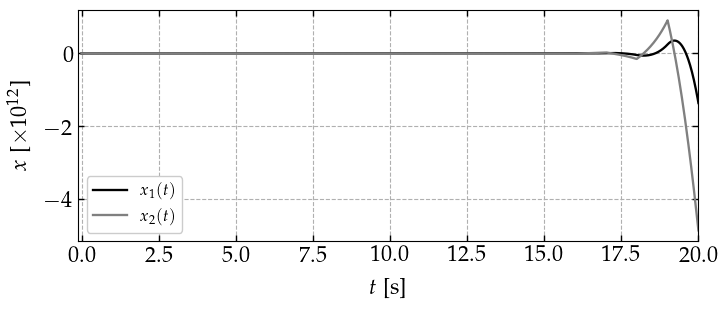

In [41]:
%matplotlib inline
fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time_history,
    [plant_output[0], plant_output[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

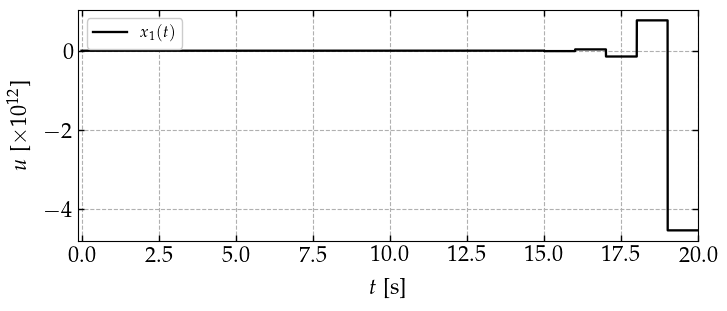

In [42]:
fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time_history, signal_control,
    label=[r'$x_1(t)$', r'$x_2(t)$'], xlabel='$t$',
    x_unit='s', x_use_prefixes=True,
    ylabel=fr'$u$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

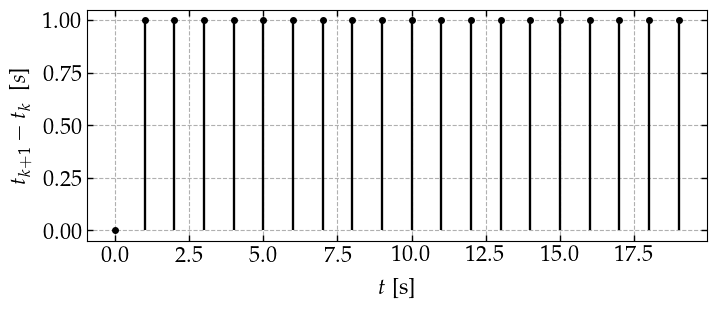

In [43]:
fig, axs = plt.subplot_mosaic([['iet']], figsize=(8, 3))
_ = gph.stem(
    axs['iet'], event_time[1:], iet_sem_mtd, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, time_history[-1]),
    ylabel='$t_{k+1} - t_k\\;$ [$s$]',
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': time_history[-1]},
         'style': {'color': "black"}})

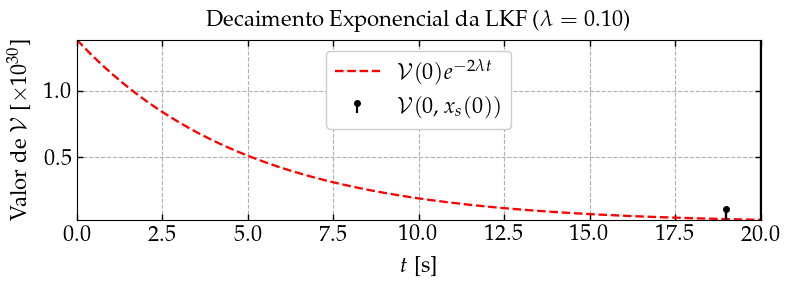

In [44]:
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 1. Grade exata de amostragem periódica
h = design_params_exp['h']
t_k_instants = np.arange(0, time_history[-1] + h, h)

if plant_output.shape[0] == nx:
  x_hist = plant_output.T
else:
  x_hist = plant_output

idx_tk_instants = [np.argmin(np.abs(time_history - tk))
                   for tk in t_k_instants if tk <= time_history[-1]]

t_k_plotted = np.array(time_history)[idx_tk_instants]

V_true_discrete = []
for idx_per in idx_tk_instants:
  x_at_tk = x_hist[idx_per].reshape(nx, 1)
  V_val = (x_at_tk.T @ P_mat @ x_at_tk)[0, 0]
  V_true_discrete.append(V_val)
V_true_discrete = np.array(V_true_discrete)

V_bound_history = V_true_discrete[0] * \
    np.exp(-2.0 * λ * np.array(time_history))

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))

_ = gph.plot(
    axs['x'], time_history, [V_bound_history],
    label=[r'$\mathcal{{V}}(0)e^{{-2\lambda t}}$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'Valor de $\mathcal{{V}}$',
    color='red', linestyle='--'
)

gph.stem(
    axs['x'], t_k_plotted, V_true_discrete,
    y_pad=(0.05, 0.05),
    x_use_prefixes=True,
    xlabel='$t$',
    x_unit='s',
    x_range=(0.0, time_history[-1]),
    ylabel=r'Valor de $\mathcal{{V}}$',
    label=r'$\mathcal{V}(0, x_s(0))$',
    cfg={
        **cfg,
        'limits': {'x_min': 0, 'x_max': time_history[-1], },
        'style': {'color': "black"}
    }
)

axs['x'].set_title(
    fr'Decaimento Exponencial da LKF ($\lambda={λ:.2f}$)', fontsize=16, pad=10)
plt.tight_layout()
plt.show()

### MTD aplicado ao ETC

In [45]:
import itertools
import numpy as np
import cvxpy as cp
from typing import Dict, Any


def control_synthesis_mtd(
    plant_data: Dict[str, Any],
    design_params: Dict[str, float],
    mtd_params: Dict[str, Any],
    eps: float = 1e-6,
    dtype=np.float32
):
  nx = plant_data['nx']
  nu = plant_data['nu']
  nρ = plant_data['nρ']
  ρ_bounds = plant_data['ρ_bounds']
  matrices_func = plant_data['matrices_func']

  h = design_params['h']
  υ = design_params['υ']
  λ = design_params['λ']

  Bnp = list(itertools.product([0, 1], repeat=nρ))
  Onx = np.zeros((nx, nx), dtype=dtype)

  n_modes = mtd_params['n_modes']
  n_regions = mtd_params['n_regions']
  pi = mtd_params['pi']

  # Pesos do Multiobjetivo Ponderado
  w_mtd = mtd_params.get(
      'w_mtd', {(p, r): 1.0 for p in range(n_modes) for r in range(n_regions)})

  # Matrizes da Planta mapeadas como parâmetros CVXPY
  A, B = {}, {}
  for i in Bnp:
    ρi = [ρ_bounds[idx][i[idx]] for idx in range(nρ)]
    mats = matrices_func(ρi)
    A[i] = cp.Parameter((nx, nx), value=mats['A'].astype(dtype))
    B[i] = cp.Parameter((nx, nu), value=mats['B'].astype(dtype))

  # Vetores de projeção e blocos auxiliares
  I_total = np.eye(5 * nx, dtype=dtype)
  e = {}
  for k in range(1, 6):
    e[k] = cp.Parameter((nx, 5 * nx), value=I_total[(k-1)*nx: k*nx, :])

  # --- Variáveis Rigorosamente Comuns Globais e Constantes ---
  X = cp.Variable((nx, nx))
  Ytil = cp.Variable((2 * nx, 5 * nx))

  # Ptil agora é declarada como estritamente GLOBAL e CONSTANTE,
  # eliminando a necessidade de restrição discreta de salto
  Ptil = cp.Variable((nx, nx), PSD=True)

  # Matrizes da looped-functional constantes e globais
  Mtil = cp.Variable((2 * nx, 2 * nx), PSD=True)
  Q1til = cp.Variable((nx, nx), symmetric=True)
  Q2til = cp.Variable((nx, nx))
  Q3til = cp.Variable((nx, nx))
  S1til = cp.Variable((nx, nx), symmetric=True)
  S2til = cp.Variable((nx, nx))
  S3til = cp.Variable((nx, nx))
  Rtil = cp.Variable((nx, nx), PSD=True)

  Rcal = cp.bmat([[Rtil, Onx], [Onx, 3 * Rtil]])

  # --- Variáveis Dependentes de Modo (p) e Região (r) ---
  # Ganhos linearizados e matrizes de acionamento mantêm total flexibilidade
  Ktil, Ξtil, Ψtil = {}, {}, {}
  for p in range(n_modes):
    for r in range(n_regions):
      Ktil[(p, r)] = cp.Variable((nu, nx))
      Ξtil[(p, r)] = cp.Variable((nx, nx), PSD=True)
      Ψtil[(p, r)] = cp.Variable((nx, nx), PSD=True)

  # Estruturas auxiliares de projeção
  Fscr = e[1].T + float(υ) * e[2].T + float(υ) * e[4].T
  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]], [e[1] + e[2] - 2 * e[3]]])

  constraints = []
  exp_λh = np.exp(-2. * λ * h)

  def He(matrix_expr):
    return matrix_expr + matrix_expr.T

  # --- Bloco 1: LMIs de Estabilização Local (Fluxo Interamostras) ---
  def get_Γ(i, p, r):
    # Acoplamento probabilístico inter-modos do ETM logo após o sorteio
    Ξtil_esp = 0
    Ψtil_esp = 0
    for q in range(n_modes):
      prob = float(pi[p, q, r])
      if prob > 0:
        Ξtil_esp = Ξtil_esp + prob * Ξtil[(q, r)]
        Ψtil_esp = Ψtil_esp + prob * Ψtil[(q, r)]

    # Os funcionais Λ utilizam as variáveis globais e unificadas
    Λ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))

    Λ2 = κ1.T @ Mtil @ κ1 - e[4].T @ Rtil @ e[4] - e[3].T @ Q1til @ e[3] + \
        He((e[1] - e[2]).T @ S1til @ e[4] + e[4].T @ S2til @ e[2] +
           e[4].T @ S3til @ e[5] + e[1].T @ Q1til @ e[3] +
           e[1].T @ Q2til @ e[2] + e[1].T @ Q3til @ e[5])

    Λ3 = e[3].T @ Q1til @ e[3] + κ1.T @ Mtil @ κ1 + \
        He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))

    # Malha fechada com ganho dependente do modo Ktil[(p, r)]
    Bscr = A[i] @ X @ e[1] + \
        B[i] @ Ktil[(p, r)] @ e[2] + B[i] @ Ktil[(p, r)] @ e[5] - X @ e[4]

    # Utiliza o Ptil unificado e global nas condições de fluxo em tau
    Θ0 = - e[5].T @ Ξtil_esp @ e[5] - 2. * λ * exp_λh * Λ1 + (1. - exp_λh) * Λ2 + \
        He(Fscr @ Bscr + e[1].T @ Ptil @ e[4] + λ * e[1].T @
           Ptil @ e[1] + 2. * λ * exp_λh * κ2.T @ Ytil)

    Θh = - e[5].T @ Ξtil_esp @ e[5] - 2. * λ * exp_λh * (Λ1 + h * Λ3 - He(κ2.T @ Ytil)) + \
        He(Fscr @ Bscr + e[1].T @ Ptil @ e[4] + λ * e[1].T @ Ptil @ e[1])

    Γ1_11 = Θ0
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil_esp
    Γ1 = cp.bmat([[Γ1_11, Γ1_12], [Γ1_21, Γ1_22]])

    Γ2_11 = Θh
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T
    Γ2_21 = Γ2_12.T
    Γ2_22 = - (np.exp(2. * λ * h) / (2. * λ * h)) * Rcal
    Γ2_23 = np.zeros((2 * nx, nx), dtype=dtype)
    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil_esp
    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  for p in range(n_modes):
    for r in range(n_regions):
      for i in Bnp:
        Λ0, Λh = get_Γ(i, p, r)
        constraints += [Λ0 << -eps * np.eye(Λ0.shape[0], dtype=dtype)]
        constraints += [Λh << -eps * np.eye(Λh.shape[0], dtype=dtype)]

      constraints += [Ψtil[(p, r)] >> eps * np.eye(nx, dtype=dtype)]
      constraints += [Ξtil[(p, r)] >> eps * np.eye(nx, dtype=dtype)]

  # --- Bloco de Restrições Marginais de Estabilidade ---
  constraints += [Ptil >> eps * np.eye(nx, dtype=dtype)]

  # --- Função Objetivo de Minimização do Traço do ETM ---
  obj_expr = 0
  for p in range(n_modes):
    for r in range(n_regions):
      weight = float(w_mtd[(p, r)]) if isinstance(
          w_mtd, dict) else float(w_mtd[p, r])
      obj_expr += weight * \
          (cp.trace(Ξtil[(p, r)]) + cp.trace(Ψtil[(p, r)]))

  obj = cp.Minimize(obj_expr)

  # --- Solução do Problema via MOSEK ---
  problem = cp.Problem(obj, constraints)
  problem.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # --- Pós-Processamento e Reconstrução Física ---
  design_results = None
  if problem.status not in ["infeasible", "unbounded"]:
    X_val = X.value.astype(dtype)
    Xinv = np.linalg.inv(X_val)
    XinvT = Xinv.T

    Xinv_2x = np.block([[Xinv, np.zeros((nx, nx), dtype=dtype)],
                        [np.zeros((nx, nx), dtype=dtype), Xinv]])
    XinvT_2x = Xinv_2x.T

    Ξ, Ψ, K = {}, {}, {}
    for p in range(n_modes):
      for r in range(n_regions):
        Ξ[(p, r)] = XinvT @ Ξtil[(p, r)].value.astype(dtype) @ Xinv
        Ψ[(p, r)] = np.linalg.inv(Ψtil[(p, r)].value.astype(dtype))
        K[(p, r)] = Ktil[(p, r)].value.astype(dtype) @ Xinv

    # P pós-processada de forma global e uniforme
    P_global = XinvT @ Ptil.value.astype(dtype) @ Xinv

    # Matrizes funcionais globais recuperadas
    R = XinvT @ Rtil.value.astype(dtype) @ Xinv
    M = XinvT_2x @ Mtil.value.astype(dtype) @ Xinv_2x
    S1 = XinvT @ S1til.value.astype(dtype) @ Xinv
    S2 = XinvT @ S2til.value.astype(dtype) @ Xinv
    S3 = XinvT @ S3til.value.astype(dtype) @ Xinv
    Q1 = XinvT @ Q1til.value.astype(dtype) @ Xinv
    Q2 = XinvT @ Q2til.value.astype(dtype) @ Xinv
    Q3 = XinvT @ Q3til.value.astype(dtype) @ Xinv

    Y = XinvT_2x @ Ytil.value.astype(dtype)

    design_results = {
        'optimal_value': problem.value,
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'functional': {
            'P': P_global,  # Retorna uma única matriz comum estável
            'R': R, 'M': M,
            'S1': S1, 'S2': S2, 'S3': S3,
            'Q1': Q1, 'Q2': Q2, 'Q3': Q3, 'Y': Y
        },
    }

  return design_results

In [46]:
import numpy as np
from datetime import datetime

n_modes = 2
n_regions = 2
SEED = 10000

design_params_exp = {**design_params, 'λ': 0.1}
rng = np.random.default_rng(SEED)
pi = np.zeros((n_modes, n_modes, n_regions), dtype=np.float32)

for r in range(n_regions):
  for p in range(n_modes):
    alpha = np.ones(n_modes) * 0.5
    pi[p, :, r] = rng.dirichlet(alpha)


design_params['υ'] = 1e-1
print("lambda (λ): ", design_params_exp['λ'])

print("Matriz de Transição de Modo (pi):")
for r in range(n_regions):
  print(f"\n📍 Região {r} (r = {r}):")
  print(np.array2string(
      pi[:, :, r],
      formatter={'float_kind': lambda x: f"{x:.2f}"}
  ))

lambda (λ):  0.1
Matriz de Transição de Modo (pi):

📍 Região 0 (r = 0):
[[0.15 0.85]
 [0.89 0.11]]

📍 Região 1 (r = 1):
[[0.50 0.50]
 [0.21 0.79]]


In [47]:

w_mtd = np.array([[0.2, 0.8],
                  [0.75, 0.25]])
print("Pesos MTD (baseados na diagonal de pi):")
print(w_mtd)

mtd_data = {
    'n_modes': n_modes,
    'n_regions': n_regions,
    'pi': pi,
    'w_mtd': w_mtd
}

print("================ CONFIGURAÇÃO AUTOMÁTICA MTD ================")

results = control_synthesis_mtd(plant_data, design_params, mtd_data)

if results is not None:
  optimal_value = results['optimal_value']
  etm_modes = results['etm']
  lyapunov_matrices = results['functional']
  K_modes = results['controller']['K']

  print("================ GLOBAL RESULTS ================")
  print(f"Optimal Value (Objective): {optimal_value:.4f}\n")
  # P global única e uniforme para garantir robustez de chaveamento
  P_lyap = lyapunov_matrices['P']
  display(Math(rf'P = {tex.mat2tex(P_lyap)}'))
  print("\n")

  print("================ MTD MODE AND REGION DEPENDENT RESULTS ================")
  for p in range(n_modes):
    print(f"\n⚡ MODE {p + 1} ⚡")
    print("=" * 30)

    for r in range(n_regions):
      print(f"\n📍 Region {r} (r = {r})")

      # Recupera as matrizes variantes de interesse real do MTD
      Ξ_pr = etm_modes['Ξ'][(p, r)]
      Ψ_pr = etm_modes['Ψ'][(p, r)]
      K_pr = K_modes[(p, r)]

      # Renderiza os parâmetros variantes legítimos da tática de defesa
      display(Math(rf'K_{{{p+1},{r}}} = {tex.mat2tex(K_pr)}'))
      display(Math(rf'\Xi_{{{p+1},{r}}} = {tex.mat2tex(Ξ_pr)}'))
      display(Math(rf'\Psi_{{{p+1},{r}}} = {tex.mat2tex(Ψ_pr)}'))
      print("-" * 30)

    print("=" * 50)
else:
  print("❌ O problema de otimização restou Inexequível (Infeasible) ou Ilimitado (Unbounded).")

Pesos MTD (baseados na diagonal de pi):
[[0.2  0.8 ]
 [0.75 0.25]]
================ CONFIGURAÇÃO AUTOMÁTICA MTD ================
================ GLOBAL RESULTS ================
Optimal Value (Objective): 0.0001



<IPython.core.display.Math object>



================ MTD MODE AND REGION DEPENDENT RESULTS ================

⚡ MODE 1 ⚡

📍 Region 0 (r = 0)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

------------------------------

📍 Region 1 (r = 1)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------


In [48]:
import numpy as np


def calcular_limites_por_decaimento(design_params, mtd_params):
  """
  Calcula analiticamente a lista de thresholds (c) para QUALQUER quantidade
  de regiões (n_regions) com base na taxa de decaimento exponencial (lambda).

  Retorna uma lista de floats com tamanho (n_regions - 1).
  """
  h = design_params['h']
  λ = design_params['λ']
  n_regions = mtd_params['n_regions']

  if n_regions <= 1:
    return []

  # Fator base de decaimento de energia em um passo amostral h
  fator_base = np.exp(-2. * λ * h)

  thresholds = []
  for k in range(1, n_regions):
    # Implementa a equação: ck = (e^(-2*lambda*h))^(n_regions - k)
    ck = float(fator_base ** (n_regions - k))
    thresholds.append(ck)

  return thresholds


def obter_regiao_por_energia(x_atual, P_comum, thresholds):
  """
  Varre a lista dinâmica de thresholds calculados por decaimento
  e descobre o índice exato da região r para o estado atual x(t).
  """
  # Calcula a energia de Lyapunov real do instante
  energia = float(x_atual.T @ P_comum @ x_atual)

  # Compara sequencialmente com os limites da progressão geométrica
  for r_idx, ck in enumerate(thresholds):
    if energia <= ck:
      return r_idx

  # Se for maior que todos os limites, pertence à última região (n_regions - 1)
  return len(thresholds)

### Sistema em Malha Fechada

In [49]:
import numpy as np


class MTD_SETM(ds.System):
  def __init__(self, Ξ_dict: dict, Ψ_dict: dict, pi_tensor: np.ndarray = None, W: np.ndarray = None, c: list = None, name: str = 'MTD_SETM'):
    super().__init__(name=name, dynamics=None, output_func=None)
    self.Ξ_dict = Ξ_dict
    self.Ψ_dict = Ψ_dict
    self.pi_tensor = pi_tensor
    self.W = W
    self.c = c

    self.current_mode = 0
    self.current_region = 0
    self.xm = None
    self.x_hat = None
    self.output_func = self._output_func

  def reset(self):
    self.current_mode = 0
    self.current_region = 0

  def switch_mode(self, x_atual: np.ndarray):
    """ Executa a comutação proativa baseada na região de energia """
    M = len(self.pi_tensor) if self.pi_tensor is not None else 1

    if self.pi_tensor is not None and self.W is not None and self.c is not None:
      x_vec = x_atual.reshape(-1, 1)
      # CORREÇÃO DO WARNING: .item() extrai o escalar de forma limpa e segura no NumPy moderno
      val = (x_vec.T @ self.W @ x_vec).item()

      self.current_region = len(self.c)
      for r_idx, ck in enumerate(self.c):
        if val <= ck:
          self.current_region = r_idx
          break

      probs = self.pi_tensor[self.current_mode, :, self.current_region]
      self.current_mode = np.random.choice(M, p=probs)
    else:
      self.current_region = 0
      self.current_mode = np.random.choice(M)

  def triggering_condition(self) -> bool:
    """ Condição de disparo elipsoidal indexada por modo e região """
    x = self.xm
    ε = self.x_hat - x

    Ψ_pr = self.Ψ_dict[(self.current_mode, self.current_region)]
    Ξ_pr = self.Ξ_dict[(self.current_mode, self.current_region)]

    x_vec = x.reshape(-1, 1)
    ε_vec = ε.reshape(-1, 1)

    # CORREÇÃO DO WARNING: .item() utilizado para evitar deprecation do NumPy 1.25+
    val = (x_vec.T @ Ψ_pr @ x_vec - ε_vec.T @ Ξ_pr @ ε_vec).item()

    return val < 0

  def _output_func(self, t: float, states: np.ndarray, inputs: dict):
    return np.array([[0.0]])

In [50]:
import numpy as np


def run_simulation(
    x0,
    duration,
    config,
    results,
    mtd_data,
):
  """
  Run the closed-loop simulation for a given initial condition.

  Parameters
  ----------
  x0 : array_like
      Initial state vector.
  duration : float
      Simulation duration in seconds.
  config : dict
      Configuration dictionary.
  results : dict
      Controller and ETM synthesis results.
  mtd_data : dict
      MTD data structure.

  Returns
  -------
  dict
      Simulation results.
  """

  # =====================================================================
  # Initialization
  # =====================================================================
  plant = ds.StateSpace(data=config["plant"], name="plant")

  sim = ds.SimulationEngineOld()
  sim.add_system(plant)

  Ξ_dict = results["etm"]["Ξ"]
  Ψ_dict = results["etm"]["Ψ"]
  K_dict = results["controller"]["K"]
  P_lyap = results["functional"]["P"]

  design_params = config["design_params"]["dspetc"]

  sampler = ds.Sampler(
      Ts=design_params["h"],
      time_source=lambda: sim.t,
  )

  thresholds_analiticos = calcular_limites_por_decaimento(
      design_params,
      mtd_data,
  )

  setm = MTD_SETM(
      Ξ_dict=Ξ_dict,
      Ψ_dict=Ψ_dict,
      pi_tensor=mtd_data.get("pi", None),
      W=P_lyap,
      c=thresholds_analiticos,
  )

  sim.add_system(setm)

  x0 = np.asarray(x0, dtype=np.float32).reshape(-1, 1)

  plant.set_initial_state(x0)

  setm.x_hat = x0.copy()
  setm.xm = x0.copy()

  sim.setup_clock(duration=duration, dt=1e-3)
  sim.reset_clock()

  sampler.reset()

  # =====================================================================
  # Histories
  # =====================================================================
  sampling_time = []
  mode_history = []
  event_time = [0.]
  signal_control = []

  K_atual = K_dict[(setm.current_mode, setm.current_region)]
  uc = (K_atual @ setm.x_hat).reshape(plant.nu, 1)

  # =====================================================================
  # Main loop
  # =====================================================================
  while sim.advance_clock():

    if plant.nu == 1:
      signal_control.append(uc.item())
    else:
      signal_control.append(uc.flatten().copy())

    default_inputs = {
        "plant": {
            "u1": uc,
        }
    }

    with sim.step(default_inputs=default_inputs):

      transmit = False

      if sampler.check():

        setm.switch_mode(plant.states)

        sampling_time.append(sim.t)
        mode_history.append(setm.current_mode)

        setm.xm = plant.states.copy()

        transmit = (
            setm.triggering_condition()
            or sim.t - event_time[-1] >= 10 * design_params["h"]
            or sim.t == 0.0
        )

      if not transmit:
        continue

      setm.x_hat = setm.xm.copy()

      event_time.append(sim.t)

      K_atual = K_dict[
          (setm.current_mode, setm.current_region)
      ]

      uc = (
          K_atual @ setm.x_hat
      ).reshape(plant.nu, 1)

  # =====================================================================
  # Post-processing
  # =====================================================================
  return {
      "time_history": sim.time_history,
      "plant_output": sim.output_history["plant"],
      "sampling_time": np.asarray(sampling_time),
      "mode_history": np.asarray(mode_history),
      "event_time": np.asarray(event_time),
      "signal_control": np.asarray(
          signal_control,
          dtype=np.float32,
      ),
  }

In [51]:
results_sim = run_simulation(
    x0=[1.0, -1.0],
    duration=20.0,
    config=config,
    results=results,
    mtd_data=mtd_data,
)

t = results_sim["time_history"]
y = results_sim["plant_output"]
events = results_sim["event_time"]
u = results_sim["signal_control"]

In [52]:
iet_com_mtd = DSPETC.get_iet(events[2:])

std_iet = np.std(iet_com_mtd)
cv_iet = std_iet / np.mean(iet_com_mtd)
event_rate = len(iet_com_mtd) / t[-1]

print(f"Resultados da Simulação (COM MTD) e SEED={SEED}:")
print("Estado Inicial: ", x0.flatten())
print("Número de amostras dos estados: ", int(t[-1] / design_params["h"]))
print("Número de transmissões de estados realizados: ", len(iet_com_mtd))

print(f"Menor IET Obtido: {min(iet_com_mtd):.2f}")
print(f"Máximo IET Obtido: {max(iet_com_mtd):.2f}")
print(
    f"Média do Intervalos de Tempo entre Eventos: {np.mean(iet_com_mtd):.2f}")

print(f"Desvio-padrão dos IETs: {std_iet:.2f}")
print(f"Coeficiente de variação dos IETs: {cv_iet:.2f}")
print(f"Taxa média de acionamentos: {event_rate:.2f} eventos/s")

Resultados da Simulação (COM MTD) e SEED=10000:
Estado Inicial:  [ 1. -1.]
Número de amostras dos estados:  20
Número de transmissões de estados realizados:  16
Menor IET Obtido: 1.00
Máximo IET Obtido: 2.00
Média do Intervalos de Tempo entre Eventos: 1.12
Desvio-padrão dos IETs: 0.33
Coeficiente de variação dos IETs: 0.29
Taxa média de acionamentos: 0.80 eventos/s


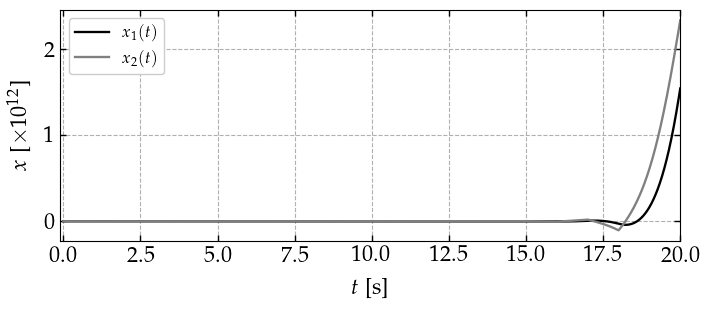

In [53]:
%matplotlib inline

y_s = np.squeeze(np.array(y)).T

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], t, [y_s[0], y_s[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

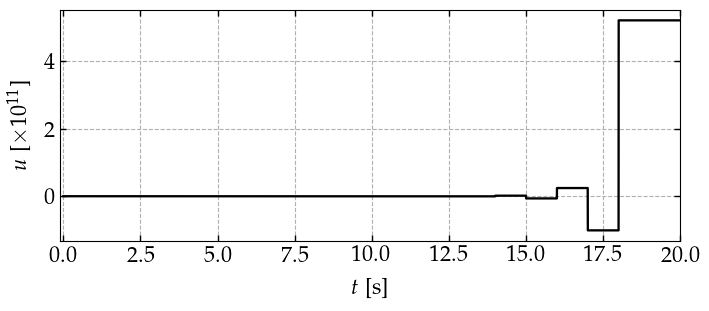

In [54]:
fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], t, u, xlabel='$t$', x_unit='s',
    x_use_prefixes=True, ylabel=fr'$u$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

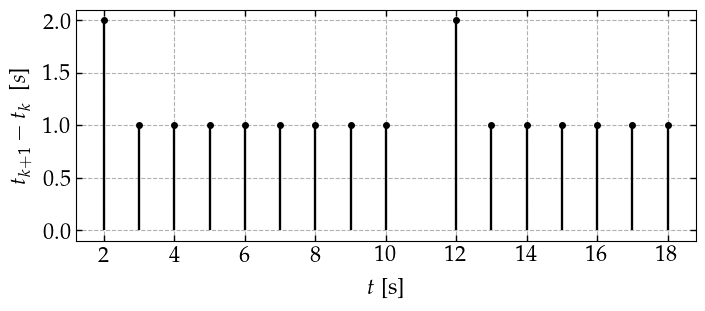

In [55]:
fig, axs = plt.subplot_mosaic([['iet']], figsize=(8, 3))

_ = gph.stem(
    axs['iet'], events[2:], iet_com_mtd, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t[-1]),
    ylabel='$t_{k+1} - t_k\\;$ [$s$]',
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t[-1]},
         'style': {'color': "black"}})

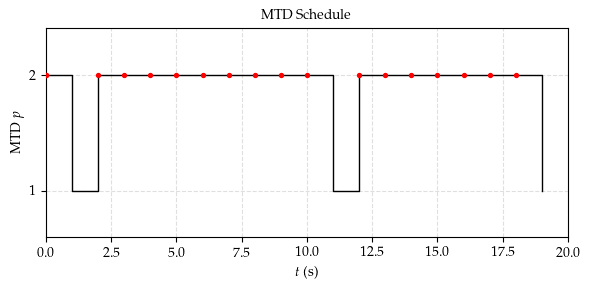

In [56]:
import numpy as np
import matplotlib.pyplot as plt


def plot_mtd_schedule_professional(sampling_time, mode_history, event_time):
  """
  Gera um painel duplo padrão IEEE para sinais de chaveamento de ultra-alta frequência.
  Esquerdo: Visão macro com atenuação visual.
  Direito: Zoom micro automático para mostrar os degraus e transmissões nítidos.
  """
  event_mode_history = []
  if len(event_time) > 0:
    for t_ev in event_time:
      idx = np.argmin(np.abs(sampling_time - t_ev))
      event_mode_history.append(mode_history[idx])
  event_mode_history = np.array(event_mode_history)

  max_mode_idx = int(np.max(mode_history))
  modos_disponiveis = list(range(1, max_mode_idx + 2))
  labels_modos = [f'{m}' for m in modos_disponiveis]

  _, axs = plt.subplot_mosaic([['macro']], figsize=(6, 3))

  axs['macro'].step(
      sampling_time, mode_history + 1,
      where='post', color='black', linewidth=1.0, alpha=1.0, label=r'$\sigma(s_m)$'
  )
  if len(event_time) > 0:
    axs['macro'].scatter(
        event_time, event_mode_history + 1,
        color='red', s=8, zorder=3, alpha=1.0, label='Transmissões'
    )
  axs['macro'].set_title('MTD Schedule',
                         fontsize=10, fontweight='bold')
  axs['macro'].set_xlabel('$t$ (s)')
  axs['macro'].set_ylabel(r'MTD $p$')
  axs['macro'].set_yticks(modos_disponiveis)
  axs['macro'].set_yticklabels(labels_modos)
  axs['macro'].set_ylim(0.6, len(modos_disponiveis) + 0.4)
  axs['macro'].set_xlim(0, t[-1])
  axs['macro'].grid(True, linestyle='--', alpha=0.4)

  plt.tight_layout()
  plt.show()


mode_history = results_sim["mode_history"]
sampling_time = results_sim["sampling_time"]
plot_mtd_schedule_professional(sampling_time, mode_history, events)

In [57]:
import numpy as np
import math


def b_approximate_entropy(x, m=2, r=0.2):
  """Calcula a Entropia de Aproximação (ApEn) de forma nativa."""
  x = np.array(x, dtype=np.float64)
  N = len(x)
  r_val = r * np.std(x)

  def _phi(m_val):
    # Gera os subvetores de comprimento m_val
    vectors = np.array([x[i: i + m_val] for i in range(N - m_val + 1)])
    # Calcula a distância de Chebyshev por broadcasting (máxima diferença absoluta)
    diff = np.max(
        np.abs(vectors[:, None, :] - vectors[None, :, :]), axis=-1)
    # Conta quantos subvetores estão dentro da tolerância r_val (inclui auto-comparação)
    counts = np.sum(diff <= r_val, axis=1)
    c_i = counts / (N - m_val + 1)
    return np.mean(np.log(c_i))

  return _phi(m) - _phi(m + 1)


def b_sample_entropy(x, m=2, r=0.2):
  """Calcula a Entropia Amostral (SampEn) de forma nativa."""
  x = np.array(x, dtype=np.float64)
  N = len(x)
  r_val = r * np.std(x)

  # Cria os vetores para a dimensão m e m+1
  vectors_m = np.array([x[i: i + m] for i in range(N - m)])
  vectors_m1 = np.array([x[i: i + m + 1] for i in range(N - m)])

  # Distâncias para dimensão m (excluindo auto-comparação)
  diff_m = np.max(
      np.abs(vectors_m[:, None, :] - vectors_m[None, :, :]), axis=-1)
  np.fill_diagonal(diff_m, np.inf)
  B = np.sum(diff_m <= r_val)

  # Distâncias para dimensão m+1 (excluindo auto-comparação)
  diff_m1 = np.max(
      np.abs(vectors_m1[:, None, :] - vectors_m1[None, :, :]), axis=-1)
  np.fill_diagonal(diff_m1, np.inf)
  A = np.sum(diff_m1 <= r_val)

  if B == 0 or A == 0:
    return np.nan
  return -np.log(A / B)


def b_permutation_entropy(x, m=2):
  """Calcula a Entropia de Permutação Normalizada (PE) de forma nativa."""
  x = np.array(x, dtype=np.float64)
  N = len(x)

  patterns = []
  for i in range(N - m + 1):
    sub = x[i: i + m]
    # Obtém os índices que ordenariam o vetor (padrão ordinal)
    patterns.append(tuple(np.argsort(sub)))

  # Contabiliza a frequência de ocorrência de cada padrão único
  _, counts = np.unique(patterns, axis=0, return_counts=True)
  probs = counts / counts.sum()

  # Entropia de Shannon básica
  shannon_ent = -np.sum(probs * np.log2(probs))

  # Normalização dividindo pelo valor máximo teórico log2(m!)
  return shannon_ent / np.log2(math.factorial(m))

In [58]:
# Rodando as funções puras
apen_res = b_approximate_entropy(iet_com_mtd, m=2, r=0.2)
sampen_res = b_sample_entropy(iet_com_mtd, m=2, r=0.2)
permen_res = b_permutation_entropy(iet_com_mtd, m=2)

print(f"Resultados com MTD:")
print(f"  -> Approximate Entropy (ApEn): {apen_res:.4f}")
print(f"  -> Sample Entropy (SampEn):    {sampen_res:.4f}")
print(f"  -> Permutation Entropy (PE):   {permen_res:.4f}")

Resultados com MTD:
  -> Approximate Entropy (ApEn): 0.2676
  -> Sample Entropy (SampEn):    0.1967
  -> Permutation Entropy (PE):   0.5665
